<a href="https://colab.research.google.com/github/AshenFdo/Blood-Request-Emergency-Classification-Model/blob/main/notebooks/Huggingface_blood_request_emegency_classification_model_fine_tuning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩸 Blood Request Emergency — Text Classification Fine-Tuning

> Fine-tuning a HuggingFace Transformer model to classify emergency blood request messages.

---

# Table of Contents

1. Import Libraries & Project Setup
2. Getting Data
3. Data Preprocessing
   - 3.1 Label Encoding
   - 3.2 Train / Test Split
   - 3.3 Tokenization
4. Evaluation Setup
5. Model Training
   - 5.1 Load Pretrained Model
   - 5.2 Create a directory for saving models
   - 5.3 Setting up training arguments with TrainingArguments
   - 5.4 Setting up Trainer
   - 5.5 Train a text classification model
   - 5.6 Inspecting the model training metrics
6. Evaluation
   - 6.1 Perform predictions on the test set
   - 6.2 Making prediction with Piepline
7. Save the model to Hugging face
8. Call the HF Model
   - 8.1 Calling the model using pytorch
   - 8.2 Calling the model using Pipeline


---

## 🎯 Project Overview

**Goal:-**  Build a fine-tuned text classification model that classify whether the blood request is emergency or not.


**Approach:**
- Base model: [`distilbert/distilbert-base-uncased`](https://huggingface.co/distilbert/distilbert-base-uncased)
- Task: Binary text classification
- Framework: `transformers` + `datasets` + `Trainer` API
- Dataset: [`AshenFdo/synthetic_blood_request_urgency_dataset`](https://huggingface.co/datasets/AshenFdo/synthetic_blood_request_urgency_dataset)

---











## 01. Import necessary libraries

In [1]:
try:
  import datasets, evaluate, accelerate
except ModuleNotFoundError:
  !pip install -U datasets evaluate accelerate gradio # -U stands for "upgrade" so we'll get the latest version by default
  import datasets, evaluate, accelerate

import random

import numpy as np
import pandas as pd

import torch

import transformers

print(f"Using transformers version: {transformers.__version__}")
print(f"Using datasets version: {datasets.__version__}")
print(f"Using torch version: {torch.__version__}")

Using transformers version: 5.10.1
Using datasets version: 5.0.0
Using torch version: 2.11.0+cu128


##02. Getting Dataset


*   The dataset used in this project is a synthetic dataset that I generated using an LLM.
*   Dataset creation notebook: - [`google-colab`](https://colab.research.google.com/drive/1uiqyCGHtfWJzFPcuxpIib2Mfk8sj1DFC?usp=sharing)
*   I uploaded it into Huggingface - [`AshenFdo/synthetic_blood_request_urgency_dataset`](https://huggingface.co/datasets/AshenFdo/synthetic_blood_request_urgency_dataset)






In [2]:
from datasets import load_dataset

dataset = load_dataset("AshenFdo/synthetic_blood_request_urgency_dataset")
dataset

README.md:   0%|          | 0.00/6.20k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/114k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['description', 'label'],
        num_rows: 2500
    })
})

In [3]:
dataset.column_names

{'train': ['description', 'label']}

In [4]:
dataset['train'][0]

{'description': 'Organizing AB+ blood for an upcoming planned operation at Kandy National Hospital.',
 'label': 'not_emergency'}

In [5]:
# Get random samples from dataset
import random

# Function to get random sampels from dataset
def get_random_sampels(dataset:datasets):
  random_idx = random.sample(range(len(dataset)),5)
  random_samples = dataset[random_idx]

  print(f"Random Samples of the Dataset\n")
  for item in zip(random_samples["description"], random_samples['label']):
    print(f'Description: {item[0]} | Label: {item[1]}')

get_random_sampels(dataset['train'])


Random Samples of the Dataset

Description: B+ blood required for ongoing medical treatments at Matara Hospital. | Label: not_emergency
Description: O- blood needed for a planned chemotherapy-related transfusion at Kandy National Hospital. | Label: not_emergency
Description: The hospital donation program at the general hospital negombo aims to maintain a steady supply of blood. | Label: not_emergency
Description: Need AB- donors for a planned surgery at Ratnapura Provincial Hospital. The operation is in two weeks, so no rush. | Label: not_emergency
Description: pls join the routine stock replenishment drive at the chilaw base hospital. your support helps us run smoothly. | Label: not_emergency


In [6]:
# Convert dataset into pandas dataframe

df = pd.DataFrame(dataset['train'], index=None)
df.head()

,description,label
0,Organizing AB+ blood for an upcoming planned o...,not_emergency
1,HOSPITAL EMERGENCY: Ratnapura Hospital urgentl...,emergency
2,O negative blood required urgently at Karapiti...,emergency
3,Our Lions Club is fulfilling a replacement don...,not_emergency
4,Looking for regular B- donors to support a pat...,not_emergency


In [7]:
df.shape

(2500, 2)

In [8]:
df['label'].value_counts()

,count
label,
not_emergency,1250
emergency,1250


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   description  2500 non-null   object
 1   label        2500 non-null   object
dtypes: object(2)
memory usage: 39.2+ KB


In [10]:
df.isnull().sum()

,0
description,0
label,0


##03. Preparing data for Text Classification (Pre-processing)

### 3.1 Label Encoding

In [11]:
# Create Mapping form id2label and label2id

id2label = {0: "not_emergency", 1:"emergency"}
label2id = {"not_emergency": 0, "emergency": 1}

print(f"Label to id: {label2id}")
print(f"Id to label: {id2label}")

Label to id: {'not_emergency': 0, 'emergency': 1}
Id to label: {0: 'not_emergency', 1: 'emergency'}


In [12]:
# Define map_labels_to_number to map label to number in data
def map_labels_to_number(example_data):
  example_data['label'] = label2id[example_data['label']]
  return example_data

# test the function
example_data  = {"description":" I need to donate blood immediately.","label":"emergency"}

map_labels_to_number(example_data)

{'description': ' I need to donate blood immediately.', 'label': 1}

In [13]:
# Map the dataset lables to numbers (0: not_emergency, 1:emergency )

dataset = dataset['train'].map(map_labels_to_number)
dataset[:5]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

{'description': ['Organizing AB+ blood for an upcoming planned operation at Kandy National Hospital.',
  'HOSPITAL EMERGENCY: Ratnapura Hospital urgently requires AB- blood for a critical patient.',
  'O negative blood required urgently at Karapitiya Hospital. We are out of time.',
  'Our Lions Club is fulfilling a replacement donor program for a patient at Anuradhapura. Join us this Friday to replace the required units.',
  'Looking for regular B- donors to support a patient with a chronic blood disorder at Jaffna Teaching Hospital.'],
 'label': [0, 1, 1, 0, 0]}

In [14]:
dataset.shuffle()[:5]

{'description': ['Looking for O+ for a scheduled transfusion at Ratnapura Hospital.',
  'My friend is getting ready for an elective surgery at Jaffna Teaching Hospital and needs O- donors to register now.',
  'Need A+ blood for a scheduled transfusion session at Negombo Hospital.',
  'annual corporate blood donation drive at the dialog axiata head office. contributing to the regular stock maintenance of the NBTS.',
  "I'm trying to organize A+ blood for my dad's upcoming hospital visit at Anuradhapura."],
 'label': [0, 0, 0, 0, 0]}

### 3.2 Train / Test Split

In [15]:
dataset = dataset.train_test_split(test_size=0.2, seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['description', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['description', 'label'],
        num_rows: 500
    })
})

In [16]:
# Get random samples from both datasets (Train and Test)
print("Random Samples from train dataset")
get_random_sampels(dataset['train'])


Random Samples from train dataset
Random Samples of the Dataset

Description: My brother's transfusion was done safely. Now we are coordinating donor arrangements to replace the blood at Batticaloa hospital. | Label: 0
Description: Kalutara hospital needs 1 pint replaced. This is a routine replacement request, you can go when you have free time. | Label: 0
Description: Urgent requirement of B+ blood at Anuradhapura Teaching Hospital. A boy met with a bike accident. Heavy internal bleeding. Please go to the blood bank and mention ward 14. | Label: 1
Description: join the routine blood camp at the colombo south teaching hospital. your regular donations help maintain our services. | Label: 0
Description: negombo hospital: AB- blood needed. hit and run crash, critical patient. | Label: 1


In [17]:
print("Random Samples from Test dataset")
get_random_sampels(dataset['test'])

Random Samples from Test dataset
Random Samples of the Dataset

Description: Hambantota hospital requires 2 pints replaced. We are looking for planned donor contributions this weekend. | Label: 0
Description: B+ donors needed for a routine hospital visit at Kalutara. | Label: 0
Description: join the routine blood camp at the kandy national hospital. we need your help to maintain our regular stocks. | Label: 0
Description: Need AB- blood for a planned blood replacement therapy at Batticaloa Teaching Hospital. | Label: 0
Description: nhsl colombo needs B- blood. hit and run. massive blood loss. | Label: 1


In [18]:
# See the distribution of  labels

train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

train_df['label'].value_counts(), test_df['label'].value_counts()

(label
 0    1001
 1     999
 Name: count, dtype: int64,
 label
 1    251
 0    249
 Name: count, dtype: int64)

The dataset is well balanced, with class labels distributed almost equally across both the training and test sets (nealy 50% per class)

### 3.3 Tokenization

Model - [`distilbert/distilbert-base-uncased`](https://huggingface.co/distilbert/distilbert-base-uncased)

In [19]:
from transformers import AutoTokenizer

tokenizer  = AutoTokenizer.from_pretrained(pretrained_model_name_or_path="distilbert/distilbert-base-uncased",use_fast=True)
tokenizer

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BertTokenizer(name_or_path='distilbert/distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [20]:
tokenizer("I need blood immediately")

{'input_ids': [101, 1045, 2342, 2668, 3202, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}

In [21]:
# Length of the tokenizer vocab
length_of_tokenizer_vocab = len(tokenizer.vocab)
print(f"Length of the tokenizer vocab: {length_of_tokenizer_vocab}")

# Maximum sequence length the tokenizer can handle
max_input_sequence = tokenizer.model_max_length
print(f"Max tokenizer input sequence: {max_input_sequence}")




Length of the tokenizer vocab: 30522
Max tokenizer input sequence: 512


In [22]:
tokenizer.vocab['emergency']

5057

In [23]:
tokenizer("Emergency!, I need A+ blood now ")

{'input_ids': [101, 5057, 999, 1010, 1045, 2342, 1037, 1009, 2668, 2085, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [24]:
# Making a preprocessing function to tokenize text
def tokenize_text(example_data):

  return tokenizer(example_data['description'],
                    padding = True,
                   truncation = True
  )

tokenize_text({'description':"Emergency!, I need A+ blood now ",'label':1})

{'input_ids': [101, 5057, 999, 1010, 1045, 2342, 1037, 1009, 2668, 2085, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [25]:
# Map tokenize_text function to Dataset.

tokenized_dataset = dataset.map(function=tokenize_text,batched=True,batch_size=100)
tokenized_dataset

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['description', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['description', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 500
    })
})

In [26]:
print(tokenized_dataset['train'][0])

{'description': 'Kalutara hospital needs 1 pint replaced. This is a routine replacement request, you can go when you have free time.', 'label': 0, 'input_ids': [101, 10556, 7630, 27115, 2902, 3791, 1015, 9231, 2102, 2999, 1012, 2023, 2003, 1037, 9410, 6110, 5227, 1010, 2017, 2064, 2175, 2043, 2017, 2031, 2489, 2051, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


## Setting Up Evaluation

In [27]:
import evaluate
import numpy as np
from typing import Tuple

accuracy_metric = evaluate.load("accuracy")

def compute_accuracy(predictions_and_labels: Tuple[np.array, np.array]):
  """
  Computes the accuracy of a model by comparing the predictions and labels.
  """
  predictions, labels = predictions_and_labels

  # Get highest prediction probability of each prediction if predictions are probabilities
  if len(predictions.shape) >= 2:
    predictions = np.argmax(predictions, axis=1)

  return accuracy_metric.compute(predictions=predictions, references=labels)

##05. Model Training

### 5.1 Load Pretrained Model

In [28]:
from transformers import AutoModelForSequenceClassification , AutoConfig

model = AutoModelForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path = "distilbert/distilbert-base-uncased",
    num_labels = 2,
    id2label = id2label,
    label2id = label2id
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [29]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [30]:
model.parameters()

<generator object Module.parameters at 0x7e88041b0120>

In [31]:
def count_param(model):
  trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
  total_parameters  = sum(p.numel() for p in model.parameters())

  return {f"trainable_parameters: { trainable_parameters} , total_parameters:{total_parameters}"}

count_param(model)

{'trainable_parameters: 66955010 , total_parameters:66955010'}

### 5.2 Create a directory for saving models

In [32]:
from pathlib import Path

model_dir = Path('models')
model_dir.mkdir(exist_ok = True)

model_save_name = "emergency_blood_request_classifier"

model_save_dir = Path(model_dir,model_save_name)

model_save_dir

PosixPath('models/emergency_blood_request_classifier')

###5.3 Setting up training arguments with TrainingArguments

In [33]:
from transformers import TrainingArguments

# Create trining arguments
training_arg = TrainingArguments(
    output_dir = model_save_dir,
    learning_rate = 0.0001,
    per_device_eval_batch_size=32,
    per_device_train_batch_size=32,
    num_train_epochs= 10,
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    save_total_limit = 3,
    use_cpu = False,
    seed  = 42,
    load_best_model_at_end =True,
    logging_strategy = 'epoch',
    report_to = 'none',
    hub_private_repo = False

)
#training_arg

### 5.4 Setting up Trainer

In [34]:
from transformers import Trainer


trainer = Trainer(
    model = model,
    args = training_arg,
    train_dataset = tokenized_dataset['train'],
    eval_dataset = tokenized_dataset['test'],
    processing_class = tokenizer,
    compute_metrics = compute_accuracy

)

### 5.5 Train a text classification model

In [35]:
results = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.095417,0.010678,0.998000
2,0.004075,0.000981,1.000000
3,0.010944,0.001672,0.998000
4,0.000132,0.000079,1.000000
5,0.000062,0.000035,1.000000
6,0.000040,0.000026,1.000000
7,0.000032,0.000021,1.000000
8,0.000027,0.000018,1.000000
9,0.000024,0.000016,1.000000
10,0.000023,0.000016,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

- The Model is so accurate.

In [36]:
for key, value in results.metrics.items():
  print(f'{key}:{value}')

train_runtime:338.2054
train_samples_per_second:59.136
train_steps_per_second:1.863
total_flos:351427729421952.0
train_loss:0.011077530461267405
epoch:10.0


In [37]:
# Save the model for later use.
print(f"Saving the model to {model_save_dir}")
trainer.save_model(output_dir=model_save_dir)

Saving the model to models/emergency_blood_request_classifier


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### 5.6 Inspecting the model training metrics

In [38]:
# Get Training history

trainer_history_all = trainer.state.log_history
trainer_history_metrics = trainer_history_all[:-1]
trainer_history_training_time = trainer_history_all[-1]
# View the first 4 metrics from the training history
trainer_history_metrics[:4]

[{'loss': 0.09541740114726717,
  'grad_norm': 0.009518051519989967,
  'learning_rate': 9.015873015873016e-05,
  'epoch': 1.0,
  'step': 63},
 {'eval_loss': 0.010678357444703579,
  'eval_accuracy': 0.998,
  'eval_runtime': 0.8568,
  'eval_samples_per_second': 583.542,
  'eval_steps_per_second': 18.673,
  'epoch': 1.0,
  'step': 63},
 {'loss': 0.004074864444278535,
  'grad_norm': 0.0027498279232531786,
  'learning_rate': 8.015873015873016e-05,
  'epoch': 2.0,
  'step': 126},
 {'eval_loss': 0.0009808896575123072,
  'eval_accuracy': 1.0,
  'eval_runtime': 0.6858,
  'eval_samples_per_second': 729.104,
  'eval_steps_per_second': 23.331,
  'epoch': 2.0,
  'step': 126}]

In [39]:
trainer_history_training_set = []
trainer_history_eval_set= []

for item in trainer_history_metrics:
  item_keys = list(item.keys())

  if any('eval' in item for item in item_keys):
    trainer_history_eval_set.append(item)

  else:
    trainer_history_training_set.append(item)


# Creating  a pandas Dataframe for traing and evalution matrix
trainer_history_training_df = pd.DataFrame(trainer_history_training_set)
trainer_history_eval_df = pd.DataFrame(trainer_history_eval_set)

trainer_history_training_df.head()

,loss,grad_norm,learning_rate,epoch,step
0,0.095417,0.009518,0.00009,1.0,63
1,0.004075,0.002750,0.00008,2.0,126
2,0.010944,0.004614,0.00007,3.0,189
3,0.000132,0.001482,0.00006,4.0,252
4,0.000062,0.001208,0.00005,5.0,315


In [40]:
trainer_history_eval_df.head()

,eval_loss,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step
0,0.010678,0.998,0.8568,583.542,18.673,1.0,63
1,0.000981,1.000,0.6858,729.104,23.331,2.0,126
2,0.001672,0.998,0.7205,693.998,22.208,3.0,189
3,0.000079,1.000,0.6402,781.024,24.993,4.0,252
4,0.000035,1.000,0.6565,761.630,24.372,5.0,315


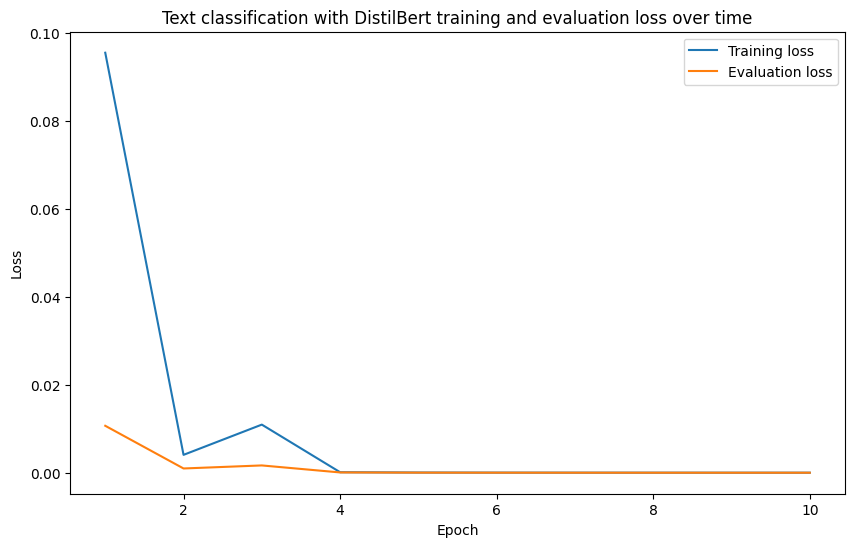

In [41]:
# Plot training and evaluation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(trainer_history_training_df["epoch"], trainer_history_training_df["loss"], label="Training loss")
plt.plot(trainer_history_eval_df["epoch"], trainer_history_eval_df["eval_loss"], label="Evaluation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Text classification with DistilBert training and evaluation loss over time")
plt.legend()
plt.show()

## 06. Evaluation

### 6.1 Perform predictions on the test set

In [42]:
prediction_all = trainer.predict(tokenized_dataset['test'])
prediction_values = prediction_all.predictions
prediction_metrics= prediction_all.metrics

print(f'Prediction metrics on the test data')
prediction_metrics

Prediction metrics on the test data


{'test_loss': 1.5938312571961433e-05,
 'test_accuracy': 1.0,
 'test_runtime': 0.7342,
 'test_samples_per_second': 680.985,
 'test_steps_per_second': 21.792}

In [43]:
prediction_values[:5]

array([[-5.716144 ,  5.3515058],
       [-5.7108054,  5.3508596],
       [ 5.841651 , -5.424729 ],
       [-5.704124 ,  5.347508 ],
       [-5.7096686,  5.36202  ]], dtype=float32)

In [44]:
from sklearn.metrics import accuracy_score

# Convert prediction values into PyTorch tensor
prediction_tensor = torch.tensor(prediction_values)

# Get the prediction probabilities by using softmax function
pred_probs = torch.softmax(prediction_tensor,dim=1)

# Get the label
predicted_label = torch.argmax(pred_probs, dim=1)

# true label
true_label = tokenized_dataset['test']['label']

# Test accuracy

test_accuracy = accuracy_score(y_pred=predicted_label,
                               y_true=true_label
                               )

print(f"Test accuracy: {test_accuracy*100}%")


Test accuracy: 100.0%


In [45]:
# Make a DataFrame of test predictions

test_predictions_df = pd.DataFrame({
    "text": dataset['test']['description'],
    "true_label":true_label,
    "predicted_label":predicted_label,
    "pred_probs":torch.max(pred_probs,dim=1).values
})

test_predictions_df.head()

,text,true_label,predicted_label,pred_probs
0,Very urgent! A negative donors needed for pati...,1,1,0.999984
1,URGENT O- blood required. Patient at Anuradhap...,1,1,0.999984
2,We need AB- donors for a planned treatment pro...,0,0,0.999987
3,Jaffna needs A+ blood. Severe blood loss durin...,1,1,0.999984
4,Urgent appeal for A+ blood at Negombo General....,1,1,0.999985


In [46]:
# Set device

def set_device():

  if torch.cuda.is_available():
    device = torch.device('cuda')
  else:
    device = torch.device('cpu')


DEVICE = set_device()
print(f"Device: {DEVICE}")

Device: None


In [47]:
test_predictions_df['is_correct'] = (
    test_predictions_df['predicted_label'] == test_predictions_df['true_label']
)

test_predictions_df['is_correct'].value_counts()

,count
is_correct,
True,500


- So All predictions are corrent

###6.2 Making prediction with Piepline

In [49]:
import torch
# Set device
def set_device():

  if torch.cuda.is_available():
    device = torch.device('cuda')
  else:
    device = torch.device('cpu')

  return device


DEVICE = set_device()
print(f"Device: {DEVICE}")

Device: cuda


In [50]:
from transformers import pipeline

BATCH_SIZE = 32
local_model_path = "/content/models/emergency_blood_request_classifier"

emergency_blood_request_classifier = pipeline(
    task="text-classification",
    model = local_model_path,
    device = DEVICE,
    top_k = 1,
    batch_size = BATCH_SIZE
)

emergency_blood_request_classifier

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

TextClassificationPipeline: {'model': 'DistilBertForSequenceClassification', 'dtype': 'float32', 'device': 'cuda', 'input_modalities': 'text'}

In [51]:
# Test  trained model on some example requests
emergency_blood_request_classifier("Hi, my brother had an accident, and the doctors asked me to arrange blood immediately")

[[{'label': 'emergency', 'score': 0.9999799728393555}]]

In [52]:
emergency_blood_request_classifier("My uncle will undergo a surgury in next weeek. I hope your help.")

[[{'label': 'not_emergency', 'score': 0.9999610185623169}]]

In [60]:
samples_request = [
    "My brother met with an accident and needs blood immediately.",
    "Urgent blood donors needed for a patient in critical condition.",
    "Doctors have requested blood withing few hours .",
    "Emergency surgery is scheduled today, and blood is required urgently.",
    "A patient in the ICU needs blood as soon as possible.",
    "Blood donors are needed for a surgery planned next week.",
    "We are looking for blood donors for a routine medical procedure.",
    "A blood donation camp will be held next month; volunteers are welcome.",
    "Please register if you are interested in donating blood in the future.",
    "We may need blood donors later this month for a scheduled treatment.",
]
emergency_blood_request_classifier(samples_request)

[[{'label': 'emergency', 'score': 0.9999834299087524}],
 [{'label': 'emergency', 'score': 0.9999841451644897}],
 [{'label': 'emergency', 'score': 0.9535029530525208}],
 [{'label': 'emergency', 'score': 0.999981164932251}],
 [{'label': 'emergency', 'score': 0.9999823570251465}],
 [{'label': 'not_emergency', 'score': 0.9999852180480957}],
 [{'label': 'not_emergency', 'score': 0.9999808073043823}],
 [{'label': 'not_emergency', 'score': 0.9999842643737793}],
 [{'label': 'not_emergency', 'score': 0.9999648332595825}],
 [{'label': 'not_emergency', 'score': 0.9999864101409912}]]

## 07. Save the model to Hugging face

In [61]:
# Save the model to Hugging face
model_upload_url = trainer.push_to_hub(
    commit_message = "Uploading Blood Request Emergency Classification model"
)

print(f"Model successfully uploaded to Hugging Face Hub with at URL: {model_upload_url}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ssifier/model.safetensors:   2%|2         | 5.87MB /  268MB            

  ...ssifier/training_args.bin:   9%|9         |   493B / 5.20kB            

Model successfully uploaded to Hugging Face Hub with at URL: https://huggingface.co/AshenFdo/emergency_blood_request_classifier/commit/ca0ad9ae81d06e19b018855e4ba64b752065c353


## 08. Call the HF Model

### 8.1 Calling the model using pytorch

In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch


tokenizer  = AutoTokenizer.from_pretrained(pretrained_model_name_or_path="AshenFdo/emergency_blood_request_classifier")
model = AutoModelForSequenceClassification.from_pretrained("AshenFdo/emergency_blood_request_classifier")

description = 'Hi, my brother had an accident, and the doctors asked me to arrange blood immediately'

inputs = tokenizer(description,return_tensors="pt")


with torch.no_grad():
  output = model(**inputs)

output_logits = output.logits
predicted_class_id = torch.argmax(output_logits,dim=1).item()
predicted_class_label = model.config.id2label[predicted_class_id]
prediction_probs = torch.softmax(output_logits,dim=1).max().item()

results = {
    "Description": description,
    "Predicted Label": predicted_class_label,
    "prediction_probs":prediction_probs
}
results

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

{'Description': 'Hi, my brother had an accident, and the doctors asked me to arrange blood immediately',
 'Predicted Label': 'emergency',
 'prediction_probs': 0.9999799728393555}

### 8.2 Calling the model using Pipeline

In [10]:
from transformers import pipeline

classifier = pipeline("text-classification", model="AshenFdo/emergency_blood_request_classifier")

samples_request = [
    "My brother met with an accident and needs blood immediately.",
    "Urgent blood donors needed for a patient in critical condition.",
    "Doctors have requested blood withing few hours .",
    "Emergency surgery is scheduled today, and blood is required urgently.",
    "A patient in the ICU needs blood as soon as possible.",
    "Blood donors are needed for a surgery planned next week.",
    "We are looking for blood donors for a routine medical procedure.",
    "A blood donation camp will be held next month; volunteers are welcome.",
    "Please register if you are interested in donating blood in the future.",
    "We may need blood donors later this month for a scheduled treatment.",
]
results = classifier(samples_request)
for req, res in zip(samples_request, results):
    print(f"[{res['label']}] {req[:60]}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[emergency] My brother met with an accident and needs blood immediately.
[emergency] Urgent blood donors needed for a patient in critical conditi
[emergency] Doctors have requested blood withing few hours .
[emergency] Emergency surgery is scheduled today, and blood is required 
[emergency] A patient in the ICU needs blood as soon as possible.
[not_emergency] Blood donors are needed for a surgery planned next week.
[not_emergency] We are looking for blood donors for a routine medical proced
[not_emergency] A blood donation camp will be held next month; volunteers ar
[not_emergency] Please register if you are interested in donating blood in t
[not_emergency] We may need blood donors later this month for a scheduled tr
